In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
from collections import defaultdict
from tqdm import tqdm

In [2]:
# Directory comtaining merged, per-chromosome PLINK files
GENOTYPE_TRAIN_DIR = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Train/chroms"
GENOTYPE_TEST_DIR = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Test/chroms"

In [3]:
# Directory containing per-cohort, per-chromosome final PLINK files
GENOTYPE_DIR = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Genotypes/final"

In [4]:
# Find all unique cohorts from .bim files
bim_files = list(Path(GENOTYPE_DIR).glob("*.bim"))
cohorts = set()
for bim_file in bim_files:
    # Extract cohort name from filename (e.g., "AnswerALS_final_chr1.bim" -> "AnswerALS")
    match = re.match(r"(.+?)_final_chr\d+\.bim", bim_file.name)
    if match:
        cohorts.add(match.group(1))
cohorts = sorted(list(cohorts))
print(f"Found cohorts: {cohorts}")


Found cohorts: ['AnswerALS', 'GTEX', 'MSBB', 'Mayo', 'NYGC', 'ROSMAP', 'ROSMAP_DLPFC']


In [5]:
# Collect statistics for each cohort and chromosome
stats_list = []

for cohort in cohorts:
    print(f"Processing cohort {cohort}...")
    for chrom in tqdm(range(1, 23)):
        bim_file = Path(GENOTYPE_DIR) / f"{cohort}_final_chr{chrom}.bim"
        
        if not bim_file.exists():
            print(f"Warning: {bim_file} not found, skipping...")
            continue
        
        # Read .bim file (no header, tab-separated)
        # Format: chromosome, variant_id, genetic_distance, position, allele1, allele2
        bim = pd.read_csv(bim_file, sep='\t', header=None, 
                         names=['chr', 'variant_id', 'genetic_dist', 'position', 'allele1', 'allele2'],
                         low_memory=False)
        
        # Calculate statistics
        bim = bim[['position', 'allele1', 'allele2']].drop_duplicates()
        total_variants = len(bim)
        unique_positions = bim['position'].nunique()
        
        # SNPs: both alleles are single characters (excluding NaN/missing values)
        # Convert to string, filter out 'nan' strings, then check length == 1
        allele1_str = bim['allele1'].astype(str)
        allele2_str = bim['allele2'].astype(str)
        is_snp = (
            (allele1_str != 'nan') & (allele2_str != 'nan') &
            (allele1_str.str.len() == 1) & (allele2_str.str.len() == 1)
        )
        n_snps = is_snp.sum()

        assert total_variants == n_snps, f"Total variants {total_variants} != n_snps {n_snps}"
        
        stats_list.append({
            'cohort': cohort,
            'chromosome': chrom,
            'total_variants': total_variants,
            'unique_positions': unique_positions
        })
    print("")


stats_df = pd.DataFrame(stats_list)
print(f"Collected statistics for {len(stats_df)} cohort-chromosome combinations")


Processing cohort AnswerALS...


  5%|▍         | 1/22 [00:11<03:56, 11.27s/it]


KeyboardInterrupt: 

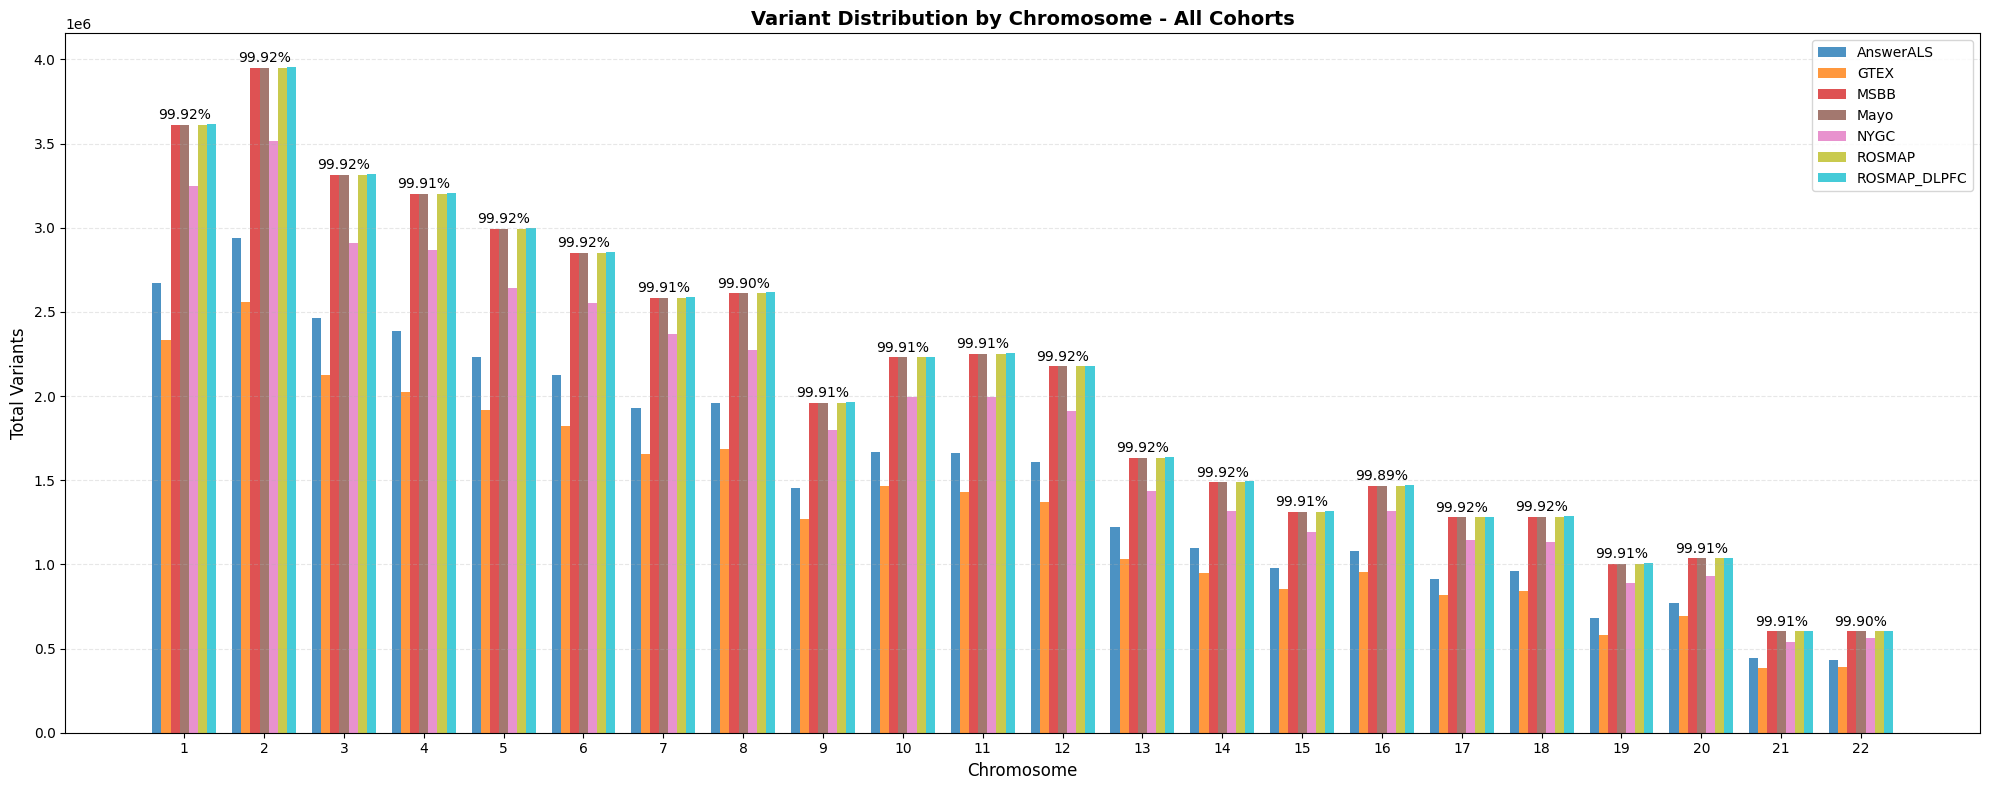

In [71]:
# Create grouped bar chart: all cohorts on same plot, grouped by chromosome
# Calculate percent unique positions for labeling
stats_df['pct_unique_positions'] = (stats_df['unique_positions'] / stats_df['total_variants'] * 100).round(2)

# Get all chromosomes present in data
chromosomes = sorted(stats_df['chromosome'].unique())
n_chromosomes = len(chromosomes)
n_cohorts = len(cohorts)
width = 0.8 / n_cohorts  # Width of bars, adjusted for number of cohorts

fig, ax = plt.subplots(figsize=(20, 8))

# Create bars for each cohort
x = np.arange(n_chromosomes)
colors = plt.cm.tab10(np.linspace(0, 1, n_cohorts))

# Align data with chromosome order
cohort_pct = []
chrom_cohort_vals = defaultdict(list)

for i, cohort in enumerate(cohorts):
    cohort_data = stats_df[stats_df['cohort'] == cohort].sort_values('chromosome')
    cohort_values = []

    for chrom in chromosomes:
        chrom_data = cohort_data[cohort_data['chromosome'] == chrom]
        if len(chrom_data) > 0:
            cohort_values.append(chrom_data['total_variants'].iloc[0])
            cohort_pct.append(chrom_data['pct_unique_positions'].iloc[0])
        else:
            cohort_values.append(0)
            cohort_pct.append(0)
        
        chrom_cohort_vals[chrom].append(cohort_values[-1])
        
    
    # Position bars for this cohort
    offset = (i - n_cohorts/2 + 0.5) * width
    bars = ax.bar(x + offset, cohort_values, width, 
                  label=cohort, alpha=0.8, color=colors[i])

# Average unique positions per chromosome label
for i, chrom in enumerate(chromosomes):
    avg_pct = sum(cohort_pct[i::n_chromosomes]) / n_cohorts
    ax.text(x[i], max(chrom_cohort_vals[chrom]) + 10000, 
            f'{avg_pct:.2f}%', 
            ha='center', va='bottom', fontsize=10, color='black')

    
# Customize plot
ax.set_xlabel('Chromosome', fontsize=12)
ax.set_ylabel('Total Variants', fontsize=12)
ax.set_title('Variant Distribution by Chromosome - All Cohorts', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(chromosomes)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
    

In [ ]:
# Collect merged train stats
train_stats_list = []
for chrom in tqdm(range(1, 23)):
    train_chr_file = Path(GENOTYPE_TRAIN_DIR) / f"clean_chr{chrom}.bim"
    if not train_chr_file.exists():
        print(f"Warning: {train_chr_file} not found, skipping...")
        continue
    bim = pd.read_csv(train_chr_file, sep='\t', header=None, 
                     names=['chr', 'variant_id', 'genetic_dist', 'position', 'allele1', 'allele2'],
                     low_memory=False)
    # Not normalized variant ids --> many duplicates
    bim = bim[['position', 'allele1', 'allele2']].drop_duplicates()

    total_snps = len(bim) # all variants in bim are snps
    unique_snps_pos = bim['position'].nunique()
    
    train_stats_list.append({
        'chromosome': chrom,
        'total_variants': total_snps,
        'unique_positions': unique_snps_pos
    })

train_stats_df = pd.DataFrame(train_stats_list)

train_stats_df['pct_unique_positions'] = (train_stats_df['unique_positions'] / train_stats_df['total_variants'] * 100).round(2)
train_stats_df.head()


100%|██████████| 22/22 [03:03<00:00,  8.35s/it]


,chromosome,total_variants,unique_positions,pct_unique_positions
0,1,6505210,6466802,99.41
1,2,7080447,7037394,99.39
2,3,5883842,5849045,99.41
3,4,5681986,5648171,99.40
4,5,5309575,5277803,99.40


In [74]:
# Save train stats
train_stats_df.to_csv(Path(GENOTYPE_TRAIN_DIR) / "variant_stats.csv", index=False)

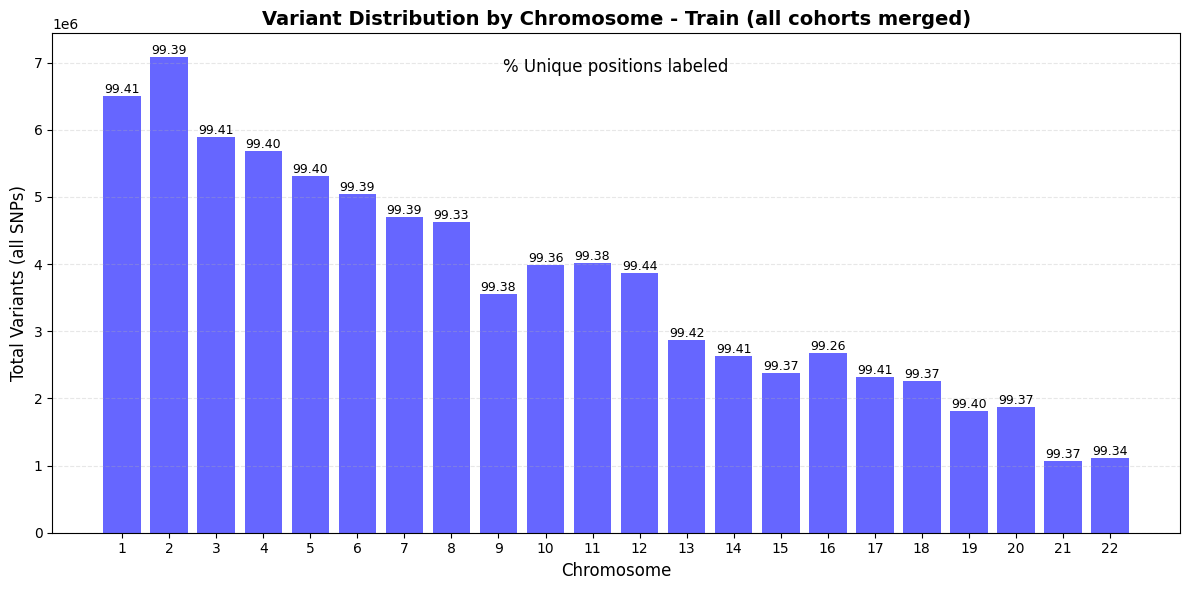

In [76]:
# Plot train stats
fig, ax = plt.subplots(figsize=(12, 6))

# Plot train stats
train_bars = ax.bar(train_stats_df['chromosome'], train_stats_df['total_variants'], 
                   label='Train', alpha=0.6, color='blue', width=0.8)

# Label percentage of unique positions
for i, row in train_stats_df.iterrows():
    ax.text(row['chromosome'], row['total_variants'], 
            f'{row["pct_unique_positions"]:.2f}', 
            ha='center', va='bottom', fontsize=9, color='black')

ax.set_xlabel('Chromosome', fontsize=12)
ax.set_ylabel('Total Variants (all SNPs)', fontsize=12)
ax.set_title('Variant Distribution by Chromosome - Train (all cohorts merged)', fontsize=14, fontweight='bold')
ax.set_xticks(train_stats_df['chromosome'])
ax.set_xticklabels(train_stats_df['chromosome'])
ax.text(0.5, 0.95, '% Unique positions labeled', transform=ax.transAxes, 
        ha='center', va='top', fontsize=12, color='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
fig.tight_layout()
plt.show()


In [ ]:
# Collect stats for test merged
test_stats_list = []
for chrom in tqdm(range(1, 23)):
    test_chr_file = Path(GENOTYPE_TEST_DIR) / f"merged_chr{chrom}.bim"
    if not test_chr_file.exists():
        print(f"Warning: {test_chr_file} not found, skipping...")
        continue
    bim = pd.read_csv(test_chr_file, sep='\t', header=None, 
                     names=['chr', 'variant_id', 'genetic_dist', 'position', 'allele1', 'allele2'],
                     low_memory=False)
    bim = bim[['position', 'allele1', 'allele2']].drop_duplicates()
    total_variants = len(bim)
    unique_positions = bim['position'].nunique()
    
    # Get snps with both alleles as single characters
    is_snp = (
        (bim['allele1'].str.len() == 1) & (bim['allele2'].str.len() == 1) &
        (bim['allele1'] != 'nan') & (bim['allele2'] != 'nan')
    )
    n_snps = is_snp.sum()
    assert total_variants == n_snps, f"Total variants {total_variants} != n_snps {n_snps}"
    
    test_stats_list.append({
        'chromosome': chrom,
        'total_variants': total_variants,
        'unique_positions': unique_positions,
    })  

test_stats_df = pd.DataFrame(test_stats_list)
test_stats_df['pct_unique_positions'] = (test_stats_df['unique_positions'] / test_stats_df['total_variants'] * 100).round(2)
test_stats_df.head()

	 chrom 1
	 chrom 2
	 chrom 3
	 chrom 4
	 chrom 5
	 chrom 6
	 chrom 7
	 chrom 8
	 chrom 9
	 chrom 10
	 chrom 11
	 chrom 12
	 chrom 13
	 chrom 14
	 chrom 15
	 chrom 16
	 chrom 17
	 chrom 18
	 chrom 19
	 chrom 20
	 chrom 21
	 chrom 22


,chromosome,total_variants,unique_positions,pct_unique_positions
0,1,3618560,3618560,100.0
1,2,3957121,3957121,100.0
2,3,3319074,3319074,100.0
3,4,3207442,3207442,100.0
4,5,2997437,2997437,100.0


In [36]:
# Save test stats
test_stats_df.to_csv(Path(GENOTYPE_TEST_DIR) / "variant_stats.csv", index=False)


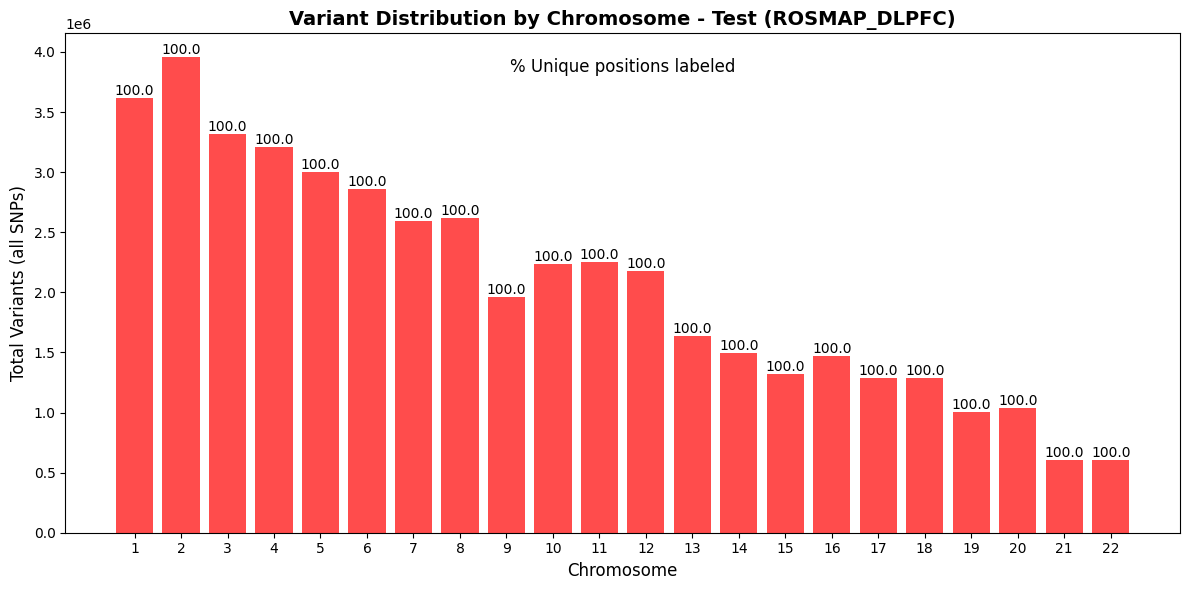

In [31]:
# Plot test stats
fig, ax = plt.subplots(figsize=(12, 6))

# Plot test stats
test_bars = ax.bar(test_stats_df['chromosome'], test_stats_df['total_variants'], 
                  label='Test', alpha=0.7, color='red', width=0.8)

# Label percentage of unique positions
for i, row in test_stats_df.iterrows():
    ax.text(row['chromosome'], row['total_variants'], 
            f'{row["pct_unique_positions"]:.1f}', 
            ha='center', va='bottom', fontsize=10, color='black')

ax.set_xlabel('Chromosome', fontsize=12)
ax.set_ylabel('Total Variants (all SNPs)', fontsize=12)
ax.set_title('Variant Distribution by Chromosome - Test (ROSMAP_DLPFC)', fontsize=14, fontweight='bold')
ax.set_xticks(test_stats_df['chromosome'])
ax.set_xticklabels(test_stats_df['chromosome'])
ax.text(0.5, 0.95, '% Unique positions labeled', transform=ax.transAxes, 
        ha='center', va='top', fontsize=12, color='black')
fig.tight_layout()
plt.show()



In [ ]:
# Check A1/A2 swapped alleles and duplicate positions
# Compare merged frequencies with original cohort frequencies

FREQ_CHECK_DIR = Path(GENOTYPE_TRAIN_DIR) / "freq_checks"
MERGED_FREQ_PATTERN = "merged_chr*.frq"
COHORT_FREQ_PATTERN = "*_chr*.frq"

def extract_bp(snp_str):
    """Extract BP from SNP column (handles both 'CHR:BP' and 'CHR:BP_A1_A2' formats)"""
    parts = str(snp_str).split(':')
    if len(parts) > 1:
        bp_part = parts[1].split('_')[0]
        return bp_part
    return None

# Optimized loading with parallel processing and dtype specification
from multiprocessing import Pool, cpu_count
from functools import partial

# Define dtype for faster loading (avoids type inference overhead)
freq_dtypes = {
    'CHR': 'int32',
    'SNP': 'string',
    'A1': 'string',
    'A2': 'string',
    'MAF': 'float32',
    'NCHROBS': 'int32'
}

def load_merged_freq_file(chrom, freq_dir):
    """Load and process a single merged frequency file"""
    merged_file = freq_dir / f"merged_chr{chrom}.frq"
    if not merged_file.exists():
        return None
    try:
        # Use dtype, engine='c', and vectorized string operations for speed
        df = pd.read_csv(merged_file, sep=r'\s+', dtype=freq_dtypes, engine='c',
                        usecols=['CHR', 'SNP', 'A1', 'A2', 'MAF', 'NCHROBS'])
        # Vectorized BP extraction (much faster than apply)
        df['BP'] = df['SNP'].str.split(':').str[1].str.split('_').str[0]
        df = df[df['BP'].notna()].copy()
        df['key'] = df['CHR'].astype(str) + ':' + df['BP'].astype(str)
        df['chromosome'] = chrom
        df['alleles_set'] = df.apply(lambda x: frozenset([x['A1'], x['A2']]), axis=1)
        return df
    except Exception as e:
        print(f"Error loading {merged_file}: {e}")
        return None

def load_cohort_freq_file(args):
    """Load and process a single cohort frequency file"""
    cohort, chrom, freq_dir = args
    cohort_file = freq_dir / f"{cohort}_chr{chrom}.frq"
    if not cohort_file.exists():
        return None
    try:
        df = pd.read_csv(cohort_file, sep=r'\s+', dtype=freq_dtypes, engine='c',
                        usecols=['CHR', 'SNP', 'A1', 'A2', 'MAF', 'NCHROBS'])
        df['BP'] = df['SNP'].str.split(':').str[1].str.split('_').str[0]
        df = df[df['BP'].notna()].copy()
        df['key'] = df['CHR'].astype(str) + ':' + df['BP'].astype(str)
        df['chromosome'] = chrom
        return (cohort, df)
    except Exception as e:
        print(f"Error loading {cohort_file}: {e}")
        return None

print("Loading frequency files (using parallel processing)...")

# Load merged frequencies in parallel
print("  Loading merged frequencies...")
with Pool(processes=min(22, cpu_count())) as pool:
    load_func = partial(load_merged_freq_file, freq_dir=FREQ_CHECK_DIR)
    merged_freqs = pool.map(load_func, range(1, 23))

# Filter out None results and concatenate
merged_freqs = [df for df in merged_freqs if df is not None]
merged_df = pd.concat(merged_freqs, ignore_index=True)
print(f"  ✓ Loaded {len(merged_df):,} variants from merged files")

# Load cohort frequencies in parallel (all cohort-chromosome combinations)
print("  Loading cohort frequencies...")
cohort_freqs = {}
train_cohorts = [c for c in cohorts if c != 'ROSMAP_DLPFC']

# Create list of all (cohort, chrom) combinations
cohort_chrom_pairs = [(cohort, chrom) for cohort in train_cohorts for chrom in range(1, 23)]

with Pool(processes=min(len(cohort_chrom_pairs), cpu_count())) as pool:
    load_args = [(cohort, chrom, FREQ_CHECK_DIR) for cohort, chrom in cohort_chrom_pairs]
    results = pool.map(load_cohort_freq_file, load_args)

# Group results by cohort
for result in results:
    if result is not None:
        cohort, df = result
        if cohort not in cohort_freqs:
            cohort_freqs[cohort] = []
        cohort_freqs[cohort].append(df)

# Concatenate per cohort
for cohort in train_cohorts:
    if cohort in cohort_freqs and cohort_freqs[cohort]:
        cohort_freqs[cohort] = pd.concat(cohort_freqs[cohort], ignore_index=True)
        print(f"  ✓ Loaded {len(cohort_freqs[cohort]):,} variants from {cohort}")

print("Frequency files loaded successfully!")


Loading frequency files (using parallel processing)...
  Loading merged frequencies...
  ✓ Loaded 100,257,111 variants from merged files
  Loading cohort frequencies...


In [ ]:
# Count variants with A1/A2 swapped between cohorts and merged
# For each cohort, compare with merged file and identify swapped alleles

swapped_results = []

for cohort in tqdm(cohorts):
    if cohort == 'ROSMAP_DLPFC' or cohort not in cohort_freqs:
        continue
    
    cohort_df = cohort_freqs[cohort].copy()
    
    # Merge with merged frequencies
    comparison = cohort_df.merge(
        merged_df,
        on='key',
        how='inner',
        suffixes=('_cohort', '_merged')
    )
    
    if len(comparison) == 0:
        continue
    
    # Detect swapped alleles (A1/A2 vs A2/A1)
    comparison['alleles_swapped'] = (
        (comparison['A1_cohort'] == comparison['A2_merged']) & 
        (comparison['A2_cohort'] == comparison['A1_merged'])
    )
    
    n_swapped = comparison['alleles_swapped'].sum()
    n_total = len(comparison)
    pct_swapped = (n_swapped / n_total * 100) if n_total > 0 else 0
    
    swapped_results.append({
        'cohort': cohort,
        'total_variants_in_both': n_total,
        'swapped_alleles': n_swapped,
        'pct_swapped': pct_swapped
    })
    
    print(f"{cohort}: {n_swapped:,} / {n_total:,} variants have swapped alleles ({pct_swapped:.2f}%)")

swapped_summary = pd.DataFrame(swapped_results)
print(f"\nSummary:")
print(swapped_summary.to_string(index=False))


  0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
# Count duplicate positions (both same set alleles and different set alleles)
# Also report MAF for swapped alleles

# Count duplicate positions in merged file
position_allele_counts = merged_df.groupby('key')['alleles_set'].nunique()
duplicate_positions = position_allele_counts[position_allele_counts > 1]
n_duplicate_positions = len(duplicate_positions)
n_total_positions = len(position_allele_counts)
pct_duplicate = (n_duplicate_positions / n_total_positions * 100) if n_total_positions > 0 else 0

print("Duplicate Positions in Merged File:")
print(f"  Total unique positions: {n_total_positions:,}")
print(f"  Positions with duplicate variants (different allele sets): {n_duplicate_positions:,} ({pct_duplicate:.2f}%)")

# For positions with duplicates, check if they have same or different allele sets
dup_pos_details = []
for pos_key in duplicate_positions.index:
    pos_variants = merged_df[merged_df['key'] == pos_key]
    unique_allele_sets = pos_variants['alleles_set'].nunique()
    n_variants = len(pos_variants)
    
    # Check if all variants have same allele set (just different order) or different sets
    if unique_allele_sets == 1:
        # Same allele set, just different A1/A2 order
        dup_type = "same_allele_set"
    else:
        # Different allele sets (true multiallelic)
        dup_type = "different_allele_set"
    
    dup_pos_details.append({
        'position': pos_key,
        'n_variants': n_variants,
        'n_unique_allele_sets': unique_allele_sets,
        'type': dup_type
    })

dup_pos_df = pd.DataFrame(dup_pos_details)
same_set_count = (dup_pos_df['type'] == 'same_allele_set').sum()
diff_set_count = (dup_pos_df['type'] == 'different_allele_set').sum()

print(f"\nBreakdown of duplicate positions:")
print(f"  Positions with same allele set (different A1/A2 order): {same_set_count:,} ({same_set_count/n_duplicate_positions*100:.2f}%)")
print(f"  Positions with different allele sets (multiallelic): {diff_set_count:,} ({diff_set_count/n_duplicate_positions*100:.2f}%)")

# Show summary by chromosome
dup_by_chr = merged_df[merged_df['key'].isin(duplicate_positions.index)].groupby('chromosome').size()
print(f"\nDuplicate variants by chromosome:")
print(dup_by_chr.to_string())


In [ ]:
# Report MAF for swapped alleles (cohort vs merged)
# For each cohort, show MAF comparison for swapped alleles

swapped_maf_results = []

for cohort in cohorts:
    if cohort == 'ROSMAP_DLPFC' or cohort not in cohort_freqs:
        continue
    
    cohort_df = cohort_freqs[cohort].copy()
    
    # Merge with merged frequencies
    comparison = cohort_df.merge(
        merged_df,
        on='key',
        how='inner',
        suffixes=('_cohort', '_merged')
    )
    
    if len(comparison) == 0:
        continue
    
    # Detect swapped alleles
    comparison['alleles_swapped'] = (
        (comparison['A1_cohort'] == comparison['A2_merged']) & 
        (comparison['A2_cohort'] == comparison['A1_merged'])
    )
    
    swapped_variants = comparison[comparison['alleles_swapped']].copy()
    
    if len(swapped_variants) > 0:
        # For swapped alleles, adjust MAF: MAF_swapped = 1 - MAF_original
        # But here we want to compare the actual MAF values, so we'll show both
        swapped_variants['MAF_cohort_original'] = swapped_variants['MAF_cohort']
        swapped_variants['MAF_cohort_adjusted'] = 1.0 - swapped_variants['MAF_cohort']
        
        # Calculate statistics
        maf_diff_original = (swapped_variants['MAF_merged'] - swapped_variants['MAF_cohort_original']).abs()
        maf_diff_adjusted = (swapped_variants['MAF_merged'] - swapped_variants['MAF_cohort_adjusted']).abs()
        
        swapped_maf_results.append({
            'cohort': cohort,
            'n_swapped': len(swapped_variants),
            'mean_maf_merged': swapped_variants['MAF_merged'].mean(),
            'mean_maf_cohort_original': swapped_variants['MAF_cohort_original'].mean(),
            'mean_maf_cohort_adjusted': swapped_variants['MAF_cohort_adjusted'].mean(),
            'mean_maf_diff_original': maf_diff_original.mean(),
            'mean_maf_diff_adjusted': maf_diff_adjusted.mean(),
            'median_maf_diff_adjusted': maf_diff_adjusted.median()
        })
        
        print(f"\n{cohort} - Swapped Alleles MAF Comparison:")
        print(f"  Number of swapped variants: {len(swapped_variants):,}")
        print(f"  Mean MAF in merged: {swapped_variants['MAF_merged'].mean():.6f}")
        print(f"  Mean MAF in cohort (original): {swapped_variants['MAF_cohort_original'].mean():.6f}")
        print(f"  Mean MAF in cohort (adjusted for swap): {swapped_variants['MAF_cohort_adjusted'].mean():.6f}")
        print(f"  Mean |MAF_diff| (original): {maf_diff_original.mean():.6f}")
        print(f"  Mean |MAF_diff| (adjusted): {maf_diff_adjusted.mean():.6f}")
        print(f"  Median |MAF_diff| (adjusted): {maf_diff_adjusted.median():.6f}")

swapped_maf_summary = pd.DataFrame(swapped_maf_results)
if len(swapped_maf_summary) > 0:
    print(f"\n\nSummary across all cohorts:")
    print(swapped_maf_summary.to_string(index=False))
